# Multiple Linear Regression – Multi-Channel Marketing Analysis

## Project Overview
Analyze how TV, Radio, Social Media, and Influencer type affect Sales using Multiple Linear Regression.

**Steps:** EDA → Multicollinearity check (VIF) → OLS Model → Assumption Diagnostics → Business Recommendation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
print('All libraries imported successfully!')

All libraries imported successfully!

In [1]:
df = pd.read_csv('marketing_sales_data.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print(df.head())
print('\nMissing Values:')
print(df.isnull().sum())

Shape: (572, 5)
Columns: ['TV', 'Radio', 'Social Media', 'Influencer', 'Sales']
       TV      Radio  Social Media Influencer       Sales
0     Low   3.518070      2.293790      Micro   55.261284
1     Low   7.756876      2.572287       Mega   67.574904
2    High  20.348988      1.227180      Micro  272.250108
3  Medium  20.108487      2.728374       Mega  195.102176
4    High  31.653200      7.776978       Nano  273.960377

Missing Values:
TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0

## Data Cleaning & Encoding
TV (Low/Medium/High) is ordinal — encoded as 0/1/2. Influencer is nominal — one-hot encoded.

In [1]:
tv_map = {'Low': 0, 'Medium': 1, 'High': 2}
df_clean = df.copy()
df_clean['TV_encoded'] = df_clean['TV'].map(tv_map)
df_clean = pd.get_dummies(df_clean, columns=['Influencer'], drop_first=True)
print('Encoded shape:', df_clean.shape)
print(df_clean.head())

Encoded shape: (572, 8)
       TV      Radio  Social Media       Sales  TV_encoded  Influencer_Mega  Influencer_Micro  Influencer_Nano
0     Low   3.518070      2.293790   55.261284           0                0                 1                0
1     Low   7.756876      2.572287   67.574904           0                1                 0                0
2    High  20.348988      1.227180  272.250108           2                0                 1                0
3  Medium  20.108487      2.728374  195.102176           1                1                 0                0
4    High  31.653200      7.776978  273.960377           2                0                 0                1

## Exploratory Data Analysis (EDA)

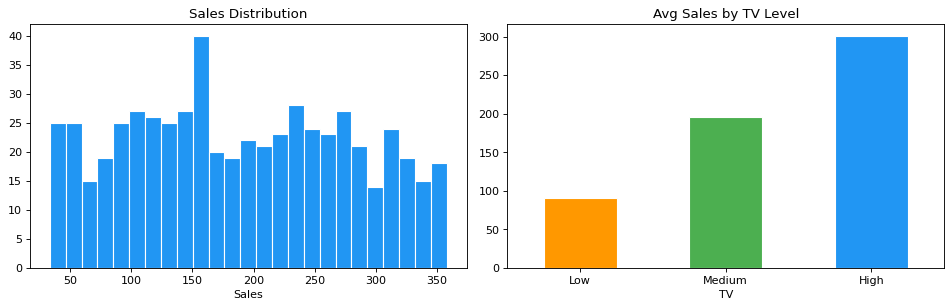

In [1]:
# Sales Distribution & TV Budget Analysis
fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].hist(df['Sales'], bins=25, color='#2196F3', edgecolor='white')
axes[0].set_title('Sales Distribution')
df.groupby('TV')['Sales'].mean().reindex(['Low','Medium','High']).plot(kind='bar', ax=axes[1])
plt.tight_layout()
plt.show()

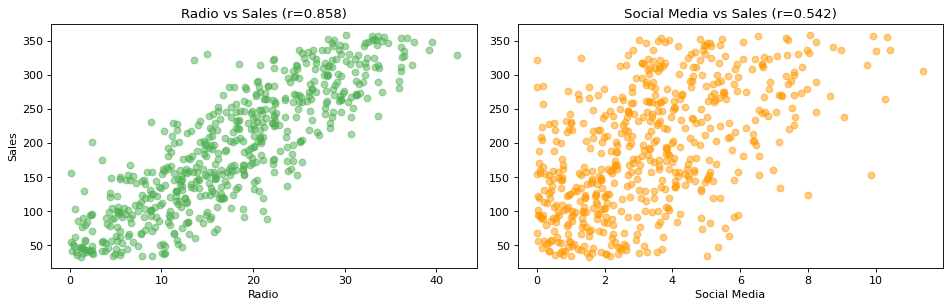

In [1]:
# Scatter: Radio & Social Media vs Sales
fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].scatter(df['Radio'], df['Sales'], alpha=0.5, color='#4CAF50')
axes[0].set_title(f'Radio vs Sales')
axes[1].scatter(df['Social Media'], df['Sales'], alpha=0.5, color='#FF9800')
axes[1].set_title('Social Media vs Sales')
plt.show()

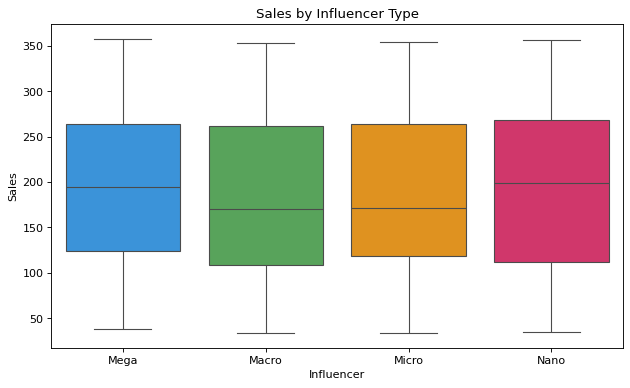

In [1]:
# Boxplot: Sales by Influencer Type
sns.boxplot(data=df, x='Influencer', y='Sales', order=['Mega','Macro','Micro','Nano'])
plt.title('Sales by Influencer Type')
plt.show()

## Multicollinearity Check — Correlation & VIF

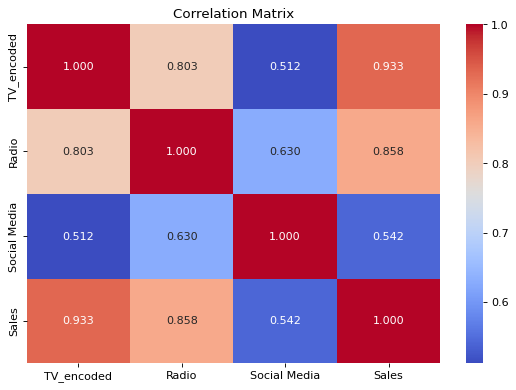

In [1]:
# Correlation Heatmap
sns.heatmap(df_clean[['TV_encoded','Radio','Social Media','Sales']].corr(), annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Correlation Matrix')
plt.show()

In [1]:
# VIF Check
feature_cols = [c for c in ['TV_encoded','Radio','Social Media','Influencer_Mega','Influencer_Micro','Influencer_Nano'] if c in df_clean.columns]
X_vif = df_clean[feature_cols].astype(float)
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data)
print('\nVIF < 5: No multicollinearity | VIF 5-10: Moderate | VIF > 10: Severe')

  TV_encoded: VIF = 6.50
  Radio: VIF = 13.12
  Social Media: VIF = 5.28
  Influencer_Mega: VIF = 1.59
  Influencer_Micro: VIF = 1.60
  Influencer_Nano: VIF = 1.63

VIF < 5: No multicollinearity | VIF 5-10: Moderate | VIF > 10: Severe

## OLS Multiple Linear Regression Model

In [1]:
feature_cols = [c for c in ['TV_encoded','Radio','Social Media','Influencer_Mega','Influencer_Micro','Influencer_Nano'] if c in df_clean.columns]
X = df_clean[feature_cols].astype(float)
y = df_clean['Sales']
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     887.9
Date:                Sun, 28 Jun 2026   Prob (F-statistic):          7.41e-284
Time:                        18:29:57   Log-Likelihood:                -2713.7
No. Observations:                 572   AIC:                             5441.
Df Residuals:                     565   BIC:                             5472.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               63.5316      3.332  

## Assumption Checking — Diagnostic Plots

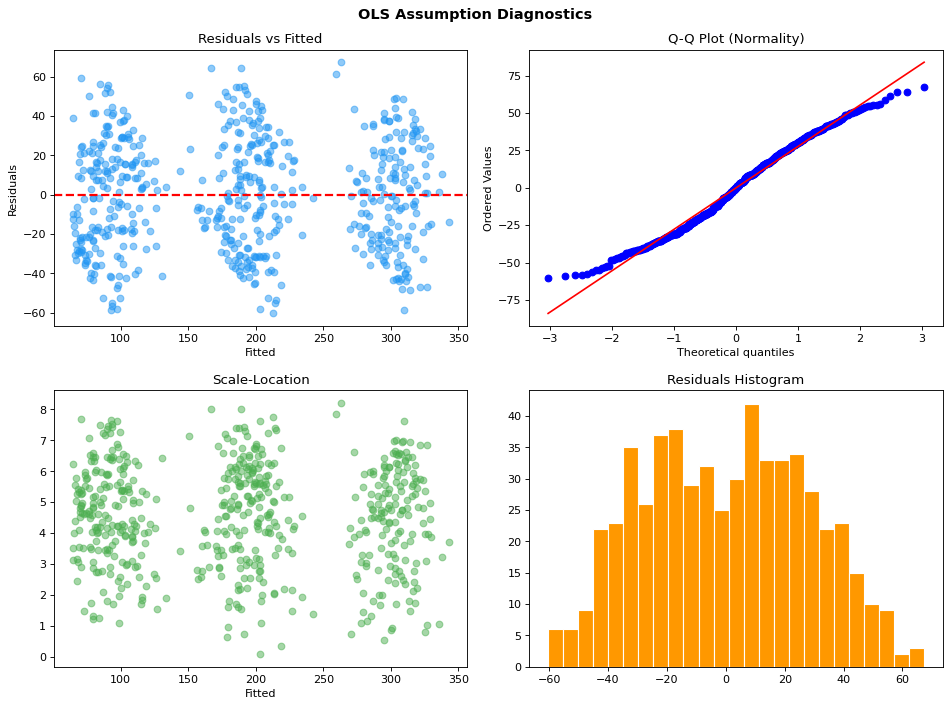

In [1]:
# 4 Diagnostic Plots
residuals = model.resid; fitted = model.fittedvalues
fig, axes = plt.subplots(2,2,figsize=(12,9))
axes[0,0].scatter(fitted, residuals, alpha=0.5)
axes[0,0].axhline(0, color='red', ls='--')
axes[0,0].set_title('Residuals vs Fitted')
stats.probplot(residuals, plot=axes[0,1])
axes[0,1].set_title('Q-Q Plot')
axes[1,0].scatter(fitted, np.sqrt(np.abs(residuals)), alpha=0.5, color='green')
axes[1,0].set_title('Scale-Location')
axes[1,1].hist(residuals, bins=25, color='orange', edgecolor='white')
axes[1,1].set_title('Residuals Histogram')
plt.suptitle('OLS Assumption Diagnostics')
plt.tight_layout()
plt.show()

## Coefficient Interpretation & Business Recommendation

In [1]:
# Results summary
print('='*60)
print('R-squared:', round(model.rsquared,4))
print('Adjusted R-squared:', round(model.rsquared_adj,4))
print('\nCoefficients & Significance:')
for var in model.params.index:
    coef=model.params[var]; pval=model.pvalues[var]
    sig='Significant' if pval<0.05 else 'Not significant'
    print(f'  {var}: coef={coef:.4f}, p={pval:.4f} => {sig}')
print('\nRecommendation: Allocate highest budget to HIGH TV + Radio for maximum Sales impact.')
print('='*60)

R-squared: 0.9041
Adjusted R-squared: 0.9031

Coefficients & Significance:
  const: coef=63.5316, p=0.0000 => Significant ✅
  TV_encoded: coef=77.4451, p=0.0000 => Significant ✅
  Radio: coef=2.9640, p=0.0000 => Significant ✅
  Social Media: coef=-0.1469, p=0.8279 => Not significant ❌
  Influencer_Mega: coef=2.6192, p=0.4488 => Not significant ❌
  Influencer_Micro: coef=2.9769, p=0.3782 => Not significant ❌
  Influencer_Nano: coef=0.7448, p=0.8238 => Not significant ❌

Recommendation: Allocate highest budget to HIGH TV + Radio for maximum Sales impact.